# Predict IDRs and generate replacements
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/02_predict_idrs.ipynb)

Predict IDR boundaries in full proteins with metapredict V3, then use their flanking context to generate replacement IDRs with IDiom.


## Setup
Use a standard Colab runtime, or select **Runtime → Change runtime type → GPU** and update `DEVICE` below.

Run cells in order. Installation is self-contained; no repository clone or account is needed. If Colab requests a session restart after installation, restart before running the imports. The first model load downloads weights.


In [ ]:
import sys

!"{sys.executable}" -m pip install -q "idiom[cookbook] @ git+https://github.com/rotskoff-group/idiom.git@v1"

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

from idiom.utils.idr_prediction import predict_idrs_fasta
from idiom.utils.notebook_helpers import example_file, save_run

started = time.perf_counter()

## Settings
Upload a full-protein FASTA through Colab’s Files pane, or use the example. Ordinary headers are sufficient.


In [2]:
INPUT_FASTA = None # Default: full HP1α protein (P45973)
DEVICE = "cpu" # "cpu" or "cuda"; "auto" uses an available GPU
MINIMUM_IDR_LENGTH = 12 # Minimum predicted IDR length in residues
OUT_DIR = Path("predicted_idrs") / time.strftime("%Y%m%d-%H%M%S") # New timestamped folder per run
MODEL_ID = "jxliu2/idiom-20M" # Pretrained IDiom model or local release directory
MAX_PROMPT_REGIONS = 2 # First predicted regions to redesign; None uses all
N_PER_REGION = 2 # Replacement IDRs generated for each selected region
BATCH_SIZE = 2 # Sequences per inference batch
SEED = 0 # Random seed
MAX_NEW_TOKENS = 128 # Generation limit, including STOP; not a fixed IDR length

## Predict and export
Existing span annotations in headers are ignored: prediction uses the full protein. The V3 domain caller uses its default boundary settings apart from the minimum IDR length.


In [3]:
input_path = INPUT_FASTA or example_file("prompted_grpo/P45973.fasta", Path("example_inputs"))
regions, audit, scores = predict_idrs_fasta(
    input_path,
    OUT_DIR,
    device=DEVICE,
    minimum_idr_length=MINIMUM_IDR_LENGTH,
)
print("Input audit:", audit.status.value_counts().to_dict())
display(regions.head(3))

print(f"Predicted {len(regions)} IDRs across {len(scores)} valid proteins.")

Input audit: {'predicted IDRs': 1}


,region_id,record_id,header,start_1based,end_1based,length
0,protein_0_region_0,protein_0,P45973_IDR_79-123,1,19,19
1,protein_0_region_1,protein_0,P45973_IDR_79-123,73,119,47


Predicted 2 IDRs across 1 valid proteins.


## Inspect one protein
Shaded spans show predicted IDRs; scores and boundaries are predictions, not experimental annotations. Positions below are 1-based.


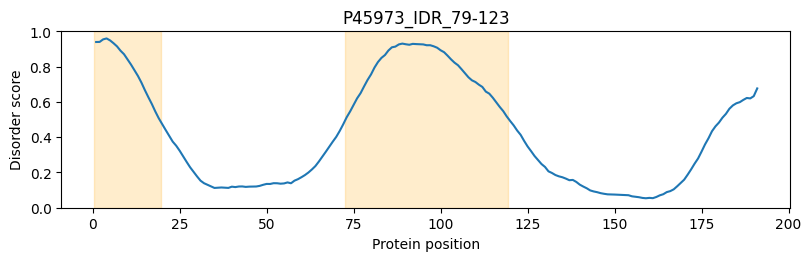

In [4]:
if scores:
    record_id = next(iter(scores))
    values = scores[record_id]
    fig, ax = plt.subplots(figsize=(8, 2.5), constrained_layout=True)
    ax.plot(range(1, len(values) + 1), values)
    for row in regions.loc[regions.record_id == record_id].itertuples():
        ax.axvspan(row.start_1based - 0.5, row.end_1based + 0.5, alpha=0.2, color="orange")
    ax.set(
        title=audit.set_index("record_id").loc[record_id, "header"],
        xlabel="Protein position",
        ylabel="Disorder score",
        ylim=(0, 1),
    )
    fig.savefig(OUT_DIR / "disorder.png", dpi=150)
    plt.show()

else:
    print("No valid protein to plot; review input_audit.csv.")

## Generate prompted IDRs
Use each selected predicted region as the replacement span. IDiom conditions on its unchanged protein flanks. Each candidate replaces one region independently in the original protein; the reconstructed FASTA updates the IDR coordinates for the new length. Generated sequences are not guaranteed to be disordered. `MAX_NEW_TOKENS` is a limit, not a fixed length.


In [5]:
import pandas as pd

from idiom import IDiom
from idiom.data.records import Record, read_records
from idiom.utils.notebook_helpers import check_context, write_fasta

if MAX_PROMPT_REGIONS is not None and MAX_PROMPT_REGIONS < 1:
    raise ValueError("MAX_PROMPT_REGIONS must be positive or None.")
if N_PER_REGION < 1:
    raise ValueError("N_PER_REGION must be positive.")
prompts = list(read_records(OUT_DIR / "annotated_proteins.fasta"))[:MAX_PROMPT_REGIONS]
rows, generated_records, redesigned = [], [], []
if prompts:
    model = IDiom.from_pretrained(MODEL_ID, device=DEVICE)
    check_context(prompts, model.model.cfg.max_seq_len, include_flanks=True)
    for region_index, prompt in enumerate(prompts):
        replacements = model.generate_prompted(
            prompt.full_seq,
            prompt.idr_start,
            prompt.idr_end,
            n=N_PER_REGION,
            batch_size=BATCH_SIZE,
            seed=SEED + region_index,
            max_new_tokens=MAX_NEW_TOKENS,
        )
        for sample, sequence in enumerate(replacements):
            generated_id = f"{prompt.accession}_sample_{sample}"
            rows.append(
                dict(
                    generated_id=generated_id,
                    region_id=prompt.accession,
                    original_idr=prompt.full_seq[prompt.idr_start : prompt.idr_end],
                    generated_idr=sequence,
                    length=len(sequence),
                    status="generated" if sequence else "empty generation",
                )
            )
            if sequence:
                generated_records.append(Record(generated_id, sequence, 0, len(sequence)))
                redesigned.append(
                    Record(
                        generated_id,
                        prompt.full_seq[: prompt.idr_start] + sequence + prompt.full_seq[prompt.idr_end :],
                        prompt.idr_start,
                        prompt.idr_start + len(sequence),
                    )
                )
else:
    print("No predicted IDRs; prompted generation was skipped.")

candidates = pd.DataFrame(
    rows, columns=["generated_id", "region_id", "original_idr", "generated_idr", "length", "status"]
)
candidates.to_csv(OUT_DIR / "prompted_sequences.csv", index=False)
write_fasta(generated_records, OUT_DIR / "prompted_idrs.fasta")
write_fasta(redesigned, OUT_DIR / "redesigned_proteins.fasta")
with pd.option_context("display.max_colwidth", 80):
    display(candidates.head(3))
print(f"Generated {len(generated_records)} nonempty replacements for {len(prompts)} predicted regions.")

,generated_id,region_id,original_idr,generated_idr,length,status
0,protein_0_region_0_sample_0,protein_0_region_0,MGKKTKRTADSSSSEDEEE,DKKEKGNEEEHKASGGRPKAPPQASSIQVL,30,generated
1,protein_0_region_0_sample_1,protein_0_region_0,MGKKTKRTADSSSSEDEEE,MATAAGAQKKSPRVFIPHEKFTLGFSGGYGKERRGYLFQQVLLHRGGSAPIPSIRGHRGATMSLPDYPGSPSYSDT...,127,generated
2,protein_0_region_1_sample_0,protein_0_region_1,MKEGENNKPREKSESNKRKSNFSNSADDIKSKKKREQSNDIARGFER,KAKGEDYAGFGDEEIGKVLEVGDKITSDCPRDVYQLVEKVEDPVEEEETEEGEDEEEDPGFPVDP,65,generated


Generated 4 nonempty replacements for 2 predicted regions.


## Results
- **`prompted_idrs.fasta`**, **`redesigned_proteins.fasta`**, and **`prompted_sequences.csv`** contain generated replacements, reconstructed proteins, and the mapping back to each predicted region. Empty generations are marked in the table and omitted from FASTA exports.
- **`idrs.fasta`** contains isolated IDRs with unique ordinary headers. Use it with `INPUT_MODE="idr"` in [embedding extraction](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/03_extract_embeddings.ipynb), [SAE interpretation](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/04_interpret_sae_features.ipynb), or [fine-tuning](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/06_finetune_and_generate.ipynb). For [signature discovery](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/05_discover_feature_signature.ipynb), prepare positive and background sets separately.
- **`annotated_proteins.fasta`** contains the full protein once per IDR, with `_IDR_start-end` headers (1-based inclusive). Use it as `PROMPT_FASTA` in [prompted generation](https://colab.research.google.com/github/rotskoff-group/idiom/blob/v1/cookbook/notebooks/01_generate_idrs.ipynb).
- **`idr_regions.csv`** maps exported IDs back to original headers and protein coordinates. Duplicate headers remain distinct.
- **`input_audit.csv`** reports invalid inputs and proteins with no predicted IDRs. Those proteins produce no FASTA entries.

Per-residue scores and prediction settings are also saved.

`run.json` records the settings and package versions. Open the output folder in Colab’s **Files** pane to download results. Download them before the runtime ends, or copy them to mounted Drive. Saved notebook previews do not include the exported files.


Saved previews show a CPU example run. Run the cells to create the exported files.

In [6]:
save_run(
    OUT_DIR,
    dict(
        input=str(input_path),
        network="V3",
        minimum_idr_length=MINIMUM_IDR_LENGTH,
        model=MODEL_ID,
        device=DEVICE,
        seed=SEED,
        max_prompt_regions=MAX_PROMPT_REGIONS,
        n_per_region=N_PER_REGION,
        max_new_tokens=MAX_NEW_TOKENS,
    ),
    elapsed=time.perf_counter() - started,
)
print("Results folder:", OUT_DIR)

Results folder: predicted_idrs/20260921-134137
